In [1]:
# Graphics and plotting.
# print('Installing mediapy:')
# !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
# !pip install --force-reinstall mediapy 


In [2]:
# !pip install matplotlib==3.5.2

In [3]:
import mujoco
import numpy as np

In [4]:
import mediapy as media
import matplotlib.pyplot as plt

def render(model, data=None, height=300, camera=-1):
  if data is None:
    data = mujoco.MjData(model)
  with mujoco.Renderer(model, 480, 640) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera)
    media.show_image(renderer.render(), height=height)

xml model of the gripper is from: https://github.com/personalrobotics/geodude_assets/tree/main

In [5]:
xml_path = "../src/robotiq_2f140/2f140.xml"

model = mujoco.MjModel.from_xml_path(xml_path) # '/workspace/gripper.urdf'

In [6]:
model

""

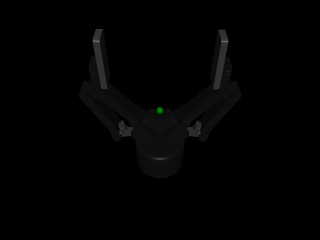

In [7]:
data = mujoco.MjData(model)

# Make renderer, render and show the pixels
with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)

    media.show_image(renderer.render())

In [8]:
model = mujoco.MjModel.from_xml_path(xml_path) # '/workspace/gripper.urdf'
data = mujoco.MjData(model)

n_frames = 60
height = 300
width = 300
frames = []

# Simulate and display video.
with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_resetData(model, data)
  for i in range(n_frames):
    while data.time < i/30.0:
      mujoco.mj_step(model, data)
    renderer.update_scene(data)
    frame = renderer.render()
    frames.append(frame)

media.show_video(frames, fps=30)

In [9]:
# ur3e_model_path = "/workspace/src/mujoco_model/ur3e.xml"
ur3e_model_path = "../src/ur3e/scene.xml"

arm_model = mujoco.MjModel.from_xml_path(ur3e_model_path)
arm_data = mujoco.MjData(arm_model)


""

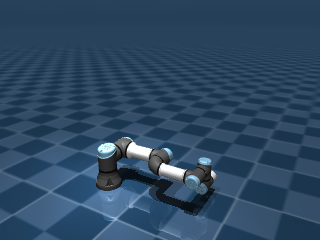

In [10]:
# Make renderer, render and show the pixels
with mujoco.Renderer(arm_model) as renderer:
    mujoco.mj_forward(arm_model, arm_data)
    renderer.update_scene(arm_data)

    media.show_image(renderer.render())

In [11]:

n_frames = 120
height = 300
width = 300
frames = []

# Simulate and display video.
with mujoco.Renderer(arm_model, height, width) as renderer:
  mujoco.mj_resetData(arm_model, arm_data)
  for i in range(n_frames):
    while arm_data.time < i/30.0:
      mujoco.mj_step(arm_model, arm_data)
    renderer.update_scene(arm_data)
    frame = renderer.render()
    frames.append(frame)

media.show_video(frames, fps=30)

This browser does not support the video tag.


From MjSpec

""

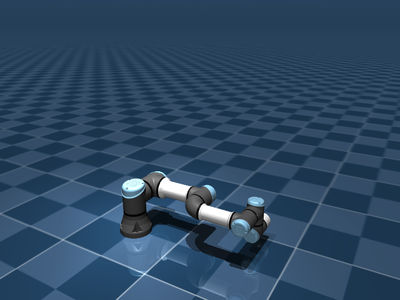

In [12]:
spec = mujoco.MjSpec.from_file(ur3e_model_path)

model = spec.compile()
render(model)

""

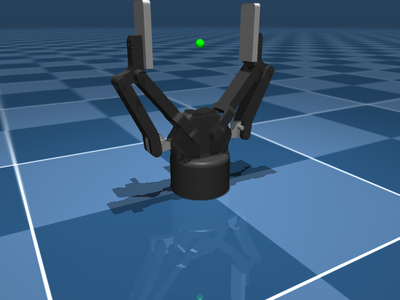

In [22]:
gripper_path = "../src/robotiq_2f140/scene.xml"
gripper_spec = mujoco.MjSpec.from_file(gripper_path)

gripper_model = gripper_spec.compile()
render(gripper_model)

In [23]:
[b.name for b in spec.bodies], [b.name for b in gripper_spec.bodies]

(['world',
  'base',
  'shoulder_link',
  'upper_arm_link',
  'forearm_link',
  'wrist_1_link',
  'wrist_2_link',
  'wrist_3_link',
  'wrist_3_linkbase_mountgripper',
  'wrist_3_linkbasegripper',
  'wrist_3_linkright_drivergripper',
  'wrist_3_linkright_couplergripper',
  'wrist_3_linkright_spring_linkgripper',
  'wrist_3_linkright_followergripper',
  'wrist_3_linkright_padgripper',
  'wrist_3_linkleft_drivergripper',
  'wrist_3_linkleft_couplergripper',
  'wrist_3_linkleft_spring_linkgripper',
  'wrist_3_linkleft_followergripper',
  'wrist_3_linkleft_padgripper'],
 ['world',
  'base_mount',
  'base',
  'right_driver',
  'right_coupler',
  'right_spring_link',
  'right_follower',
  'right_pad',
  'left_driver',
  'left_coupler',
  'left_spring_link',
  'left_follower',
  'left_pad',
  'object'])

""

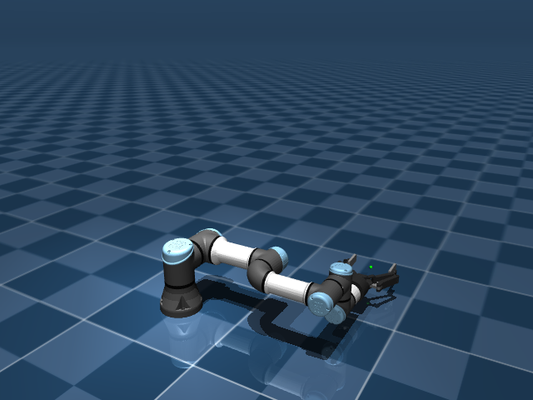

In [24]:
spec = mujoco.MjSpec.from_file(ur3e_model_path)
spec.copy_during_attach = True

# Get the torso, arm, and leg bodies
flange = spec.body('wrist_3_link')

gripper_base_mount = gripper_spec.body('base_mount')

# Attach frames at the site positions
attachment_site = flange.sites[0]

# Add new legs
attachment_site.attach_body(gripper_base_mount, 'wrist_3_link', 'gripper')

model = spec.compile()
render(model, height=400)

# 4. Save the combined structural layout out to a clean XML file
with open("combined_robot_gripper.xml", "w") as f:
    f.write(spec.to_xml())

""

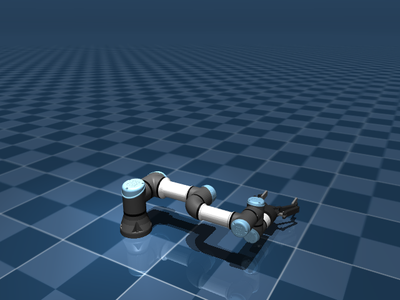

In [19]:
combined_robot_path = "../src/reach_skill/combined_robot_gripper.xml"
combined_robot_spec = mujoco.MjSpec.from_file(combined_robot_path)

combined_robot_model = combined_robot_spec.compile()
render(combined_robot_model)

In [16]:
model.site("attachment_site").pos, model.site("attachment_site")
data.site("attachment_site").xpos, data.site("attachment_site").xpos, data.site("attachment_site").xvel

KeyError: "Invalid name 'attachment_site'. Valid names: ['grasp_site']"

In [ ]:
site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
data.site("attachment_site").xpos, data.site_xpos, data.site("attachment_site").id


(array([ 2.31900324e-01, -3.14429401e-04,  6.93599747e-01]),
 array([[ 2.31900324e-01, -3.14429401e-04,  6.93599747e-01],
        [ 3.38900290e-01, -2.29222443e-04,  6.93599747e-01]]),
 0)

""

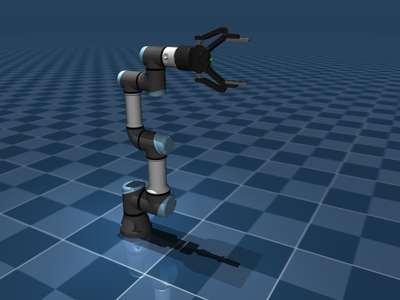

In [ ]:
data = mujoco.MjData(model)
data.qpos[0:2] = [-1.57, -1.57]

data.qpos[2] = 0

data.qpos[3] = -1.57
data.qpos[4] = 0

data.qpos[5] = 1.57

data.qpos[6] = 0

gripper_value = 0.1 # Range [0.0, 0.8]
data.qpos[7] = -gripper_value
data.qpos[8] = -gripper_value
data.qpos[9] = gripper_value

data.qpos[10] = 0
data.qpos[11] = -gripper_value
data.qpos[12] = -gripper_value

data.qpos[13] = gripper_value

with mujoco.Renderer(model, 480, 640) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    media.show_image(renderer.render(), height=height)

if True:
    mujoco.mj_saveLastXML("ur3e_with_gripper.xml", model)


In [ ]:
data.qpos, data.qvel, model.nu, len(data.qvel)

(array([-1.57, -1.57,  0.  , -1.57,  0.  ,  1.57,  0.  , -0.1 , -0.1 ,
         0.1 ,  0.  , -0.1 , -0.1 ,  0.1 ]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 7,
 14)

In [ ]:
data = mujoco.MjData(model)

# Episode parameters.
duration = 3       # (seconds)
framerate = 60     # (Hz)
data.qpos[0:2] = [-.5, -.5]  # Initial x-y position (m)
data.qvel[2] = 4   # Initial vertical velocity (m/s)
ctrl_phase = 2 * np.pi * np.random.rand(model.nu)  # Control phase
ctrl_freq = 1     # Control frequency

# Simulate and render.
frames = []
with mujoco.Renderer(model, 480, 640) as renderer:
  while data.time < duration:
    # Sinusoidal control signal.
    data.ctrl = np.sin(ctrl_phase + 2 * np.pi * data.time * ctrl_freq)
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      # This draws the regular humanoid from `data`.
      renderer.update_scene(data)

      # Render and add the frame.
      pixels = renderer.render()
      frames.append(pixels)

# Render video at half real-time.
media.show_video(frames, fps=framerate/2)

This browser does not support the video tag.


In [ ]:
data = mujoco.MjData(model)
data2 = mujoco.MjData(model)

# Episode parameters.
duration = 3       # (seconds)
framerate = 60     # (Hz)
data.qpos[0:2] = [-.5, -.5]  # Initial x-y position (m)
data.qvel[2] = 4   # Initial vertical velocity (m/s)
ctrl_phase = 2 * np.pi * np.random.rand(model.nu)  # Control phase
ctrl_freq = 1     # Control frequency

# Simulate and render.
frames = []
with mujoco.Renderer(model, 480, 640) as renderer:
  while data.time < duration:
    # Sinusoidal control signal.
    data.ctrl = np.sin(ctrl_phase + 2 * np.pi * data.time * ctrl_freq)
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      # This draws the regular humanoid from `data`.
      renderer.update_scene(data)

      # Render and add the frame.
      pixels = renderer.render()
      frames.append(pixels)

# Render video at half real-time.
media.show_video(frames, fps=framerate/2)

This browser does not support the video tag.
